<a href="https://www.kaggle.com/code/lalit7881/restaurant-re-views-for-nlp-eda-76-90?scriptVersionId=345594054" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mawro73/restaurant-reviews-for-nlp/Restaurant_Reviews.tsv


## Loading dataset

In [2]:
file_path = "/kaggle/input/datasets/mawro73/restaurant-reviews-for-nlp/Restaurant_Reviews.tsv"

df = pd.read_csv(file_path, sep="\t")

print(df.head())
print(df.shape)
print(df.columns)

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1
(1000, 2)
Index(['Review', 'Liked'], dtype='object')


In [3]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(4)

In [5]:
df.columns

Index(['Review', 'Liked'], dtype='object')

In [6]:
df.nunique()

Review    996
Liked       2
dtype: int64

## Loading dataset

In [7]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [8]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
stopword = nltk.corpus.stopwords.words('english')
stopword

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [10]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
wn = nltk.WordNetLemmatizer()

In [12]:
sentance = ["good movie","not a good movie","did not like","i like it","good one"]

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

#unique Value
vectorizer = CountVectorizer()
feature_cv = vectorizer.fit_transform(sentance)
print(feature_cv.shape)
print("Sparse Matrix : \n",feature_cv)
feature_cv = pd.DataFrame(feature_cv.toarray())
feature_cv.columns = vectorizer.get_feature_names_out()
feature_cv

(5, 7)
Sparse Matrix : 
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (5, 7)>
  Coords	Values
  (0, 1)	1
  (0, 4)	1
  (1, 1)	1
  (1, 4)	1
  (1, 5)	1
  (2, 5)	1
  (2, 0)	1
  (2, 3)	1
  (3, 3)	1
  (3, 2)	1
  (4, 1)	1
  (4, 6)	1


,did,good,it,like,movie,not,one
0,0,1,0,0,1,0,0
1,0,1,0,0,1,1,0
2,1,0,0,1,0,1,0
3,0,0,1,1,0,0,0
4,0,1,0,0,0,0,1


In [14]:
vectorizer = CountVectorizer(ngram_range=(1,3))
feature_cv = vectorizer.fit_transform(sentance)
print(feature_cv.shape)
print("Sparse Matrix : \n",feature_cv)
feature_cv = pd.DataFrame(feature_cv.toarray())
feature_cv.columns = vectorizer.get_feature_names_out()
feature_cv

(5, 15)
Sparse Matrix : 
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 21 stored elements and shape (5, 15)>
  Coords	Values
  (0, 3)	1
  (0, 9)	1
  (0, 4)	1
  (1, 3)	1
  (1, 9)	1
  (1, 4)	1
  (1, 10)	1
  (1, 11)	1
  (1, 12)	1
  (2, 10)	1
  (2, 0)	1
  (2, 7)	1
  (2, 1)	1
  (2, 13)	1
  (2, 2)	1
  (3, 7)	1
  (3, 6)	1
  (3, 8)	1
  (4, 3)	1
  (4, 14)	1
  (4, 5)	1


,did,did not,did not like,good,good movie,good one,it,like,like it,movie,not,not good,not good movie,not like,one
0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0
1,0,0,0,1,1,0,0,0,0,1,1,1,1,0,0
2,1,1,1,0,0,0,0,1,0,0,1,0,0,1,0
3,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1


In [15]:
new_df = df.copy()

In [16]:
new_df['Review'] = new_df['Review'].str.lower()

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000  
max_len = 100   

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(new_df['Review'])

sequences = tokenizer.texts_to_sequences(new_df['Review'])
X = pad_sequences(sequences, maxlen=max_len)

In [18]:
y = df['Liked']
np.unique(y)

array([0, 1])

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64),
    Dense(5, activation='sigmoid')
])

model.summary()

2026-08-28 11:29:36.852078: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.layers import LSTM
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(max_len,)),
    LSTM(64),
    Dense(5, activation='sigmoid')
])
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,733 (5.07 MB)

 Trainable params: 1,329,733 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
# Learning rate reduction when val_accuracy plateaus
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=1e-6
)

#  Stop early if validation loss doesn’t improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#  Save the best model (highest val_accuracy)
model_ckpt = ModelCheckpoint(
    "best_RNN_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

#  Callbacks list
callbacks = [learning_rate_reduction, early_stop, model_ckpt]

epochs = 100
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=32,      
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4626 - loss: 1.3459
Epoch 1: val_accuracy improved from None to 0.51000, saving model to best_RNN_model.keras

Epoch 1: finished saving model to best_RNN_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.4963 - loss: 1.0778 - val_accuracy: 0.5100 - val_loss: 0.7209 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5701 - loss: 0.7000
Epoch 2: val_accuracy improved from 0.51000 to 0.56500, saving model to best_RNN_model.keras

Epoch 2: finished saving model to best_RNN_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5888 - loss: 0.6906 - val_accuracy: 0.5650 - val_loss: 0.6803 - learning_rate: 0.0010
Epoch 3/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7120 - loss: 0.6257
Epoch 3: val_accuracy improved from 0.56500 to 0.62500, saving model to best_RNN_model.keras

Epoch 3: finished saving model to best_RNN_model.keras
25/25 ━━━━━━━━━━━━

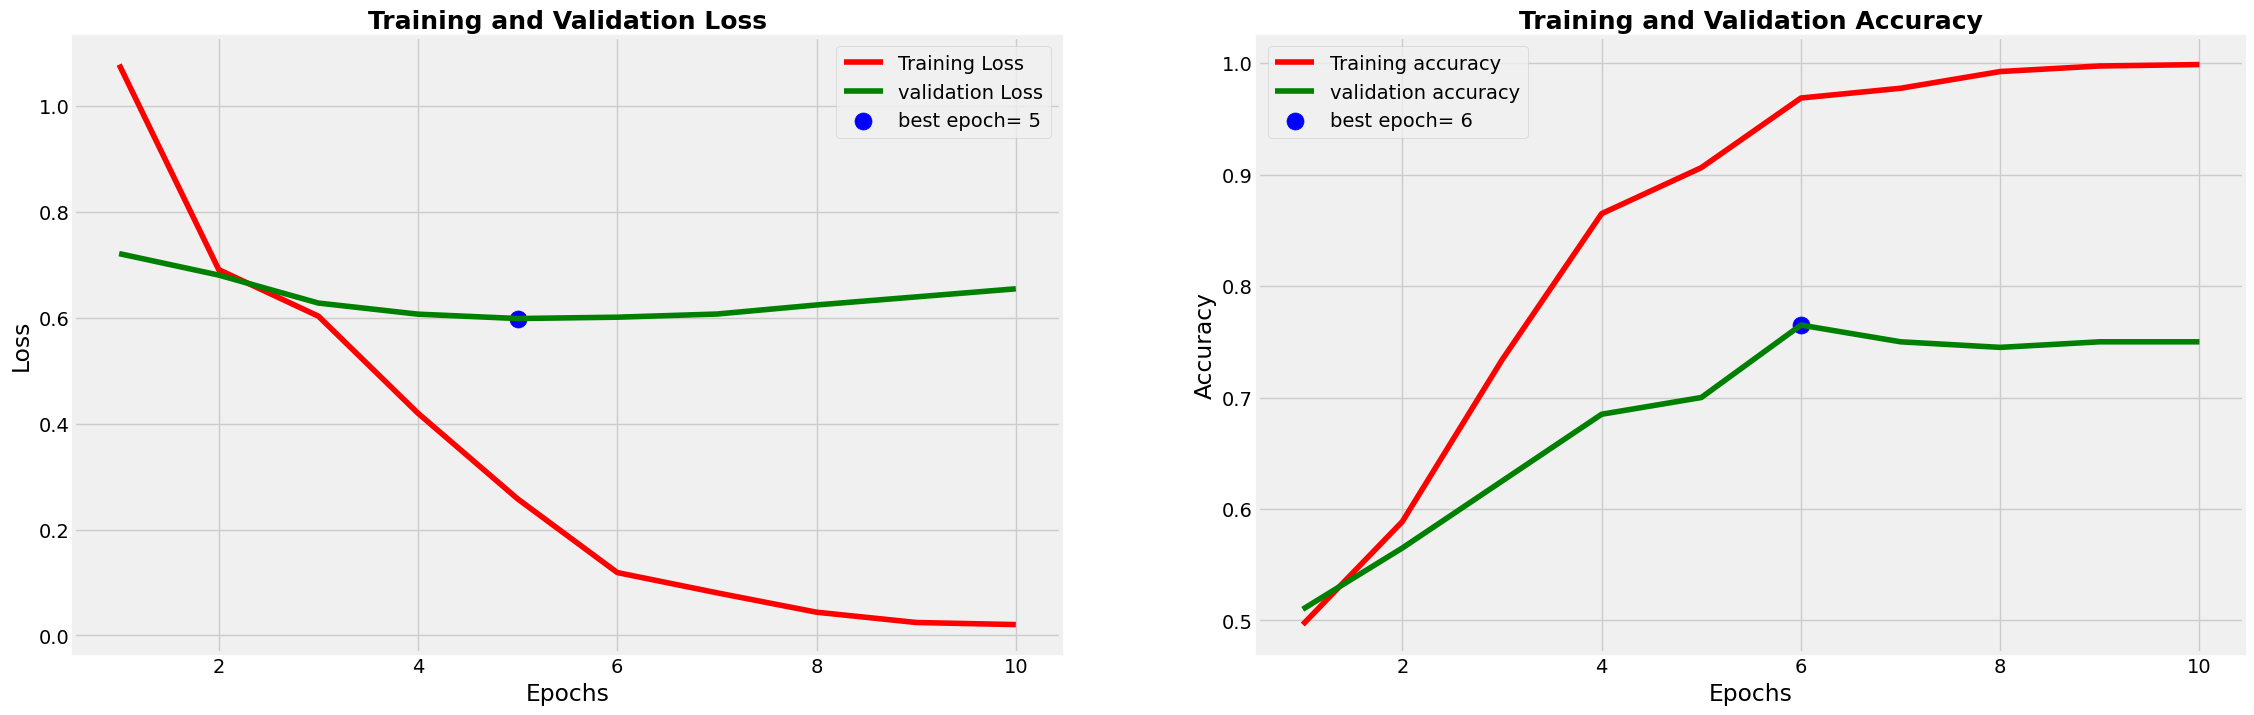

In [23]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'


plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()


In [24]:
# Evaluate on train, validation, and test sets
train_score = model.evaluate(X_train, y_train, verbose=1)
valid_score = model.evaluate(X_val, y_val, verbose=1)


# Print results
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9500 - loss: 0.1705
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7000 - loss: 0.5984
Train Loss:  0.17052918672561646
Train Accuracy:  0.949999988079071
--------------------
Validation Loss:  0.5983672142028809
Validation Accuracy:  0.699999988079071


## Thank you..pls upvote!!!!!!!!